<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Fase III: Multi-Stage Simulation Tasks</h3>

<ul>
  <li><b>Task 1:</b> Benchmark analítico 2 cuerpos (Tierra–satélite)</li>
  <li><b>Task 2:</b> Sistema restringido 3 cuerpos (Tierra–Luna–satélite)</li>
  <li><b>Task 3:</b> Expansión <i>N-body</i> 3D (Sol–Mercurio)</li>
</ul>

</div>


In [ ]:

!pip install emoji

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

G = 6.67430e-11
DAY = 86400.0
AU = 1.495978707e11

M_EARTH = 5.97219e24
M_MOON = 7.342e22
M_SAT = 4.19e5
M_SUN = 1.98847e30
M_MERCURY = 3.3011e23


In [2]:


def compute_accelerations(positions, masses, softening=0.0):
    n = positions.shape[0]
    acc = np.zeros_like(positions, dtype=float)
    for i in range(n):
        r_ij = positions - positions[i]
        dist2 = np.sum(r_ij*r_ij, axis=1) + softening**2
        inv_dist3 = np.zeros(n)
        mask = dist2 > 0
        inv_dist3[mask] = dist2[mask]**(-1.5)
        acc[i] = np.sum(r_ij * (G*masses*inv_dist3)[:,None], axis=0)
    return acc

def step_rk4(r, v, masses, dt):
    a1 = compute_accelerations(r, masses)
    k1r, k1v = v, a1
    a2 = compute_accelerations(r + 0.5*dt*k1r, masses)
    k2r, k2v = v + 0.5*dt*k1v, a2
    a3 = compute_accelerations(r + 0.5*dt*k2r, masses)
    k3r, k3v = v + 0.5*dt*k2v, a3
    a4 = compute_accelerations(r + dt*k3r, masses)
    k4r, k4v = v + dt*k3v, a4
    r_next = r + (dt/6.0)*(k1r + 2*k2r + 2*k3r + k4r)
    v_next = v + (dt/6.0)*(k1v + 2*k2v + 2*k3v + k4v)
    return r_next, v_next

def simulate(positions0, velocities0, masses, dt, n_steps):
    n = len(masses)
    pos = np.zeros((n_steps+1, n, 3))
    vel = np.zeros((n_steps+1, n, 3))
    t = np.arange(n_steps+1)*dt
    r, v = positions0.copy(), velocities0.copy()
    pos[0], vel[0] = r, v
    for k in range(1, n_steps+1):
        r, v = step_rk4(r, v, masses, dt)
        pos[k], vel[k] = r, v
    return {"time": t, "positions": pos, "velocities": vel}


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Task 1</h3>

</div>

In [3]:
# Task 1: Tierra + satélite
alt = 420e3
r_orbit = 6371e3 + alt
v_circ = np.sqrt(G*M_EARTH/r_orbit)

r0 = np.array([[0,0,0], [r_orbit,0,0]], dtype=float)
v0 = np.array([[0,0,0], [0,v_circ,0]], dtype=float)
masses = np.array([M_EARTH, M_SAT], dtype=float)

dt = 10.0
n_steps = int(2*DAY/dt)
res1 = simulate(r0, v0, masses, dt, n_steps)


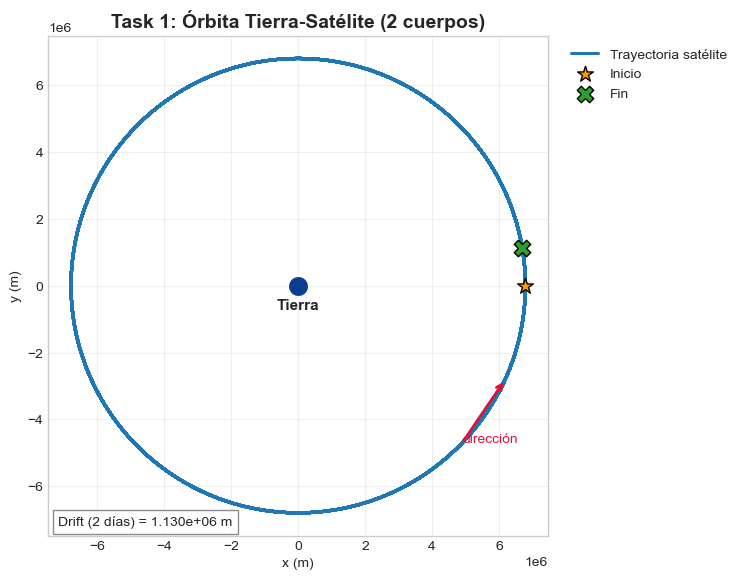

Task 1 drift posición (2 días): 1.130e+06 m


In [4]:
p = res1["positions"][:,1,:]
x, y = p[:,0], p[:,1]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7.5,7.5))

# trayectoria
ax.plot(x, y, color="#1f77b4", lw=2.2, label="Trayectoria satélite")

# Tierra
ax.scatter(0, 0, s=220, color="#0b3d91", edgecolor="white", linewidth=1.2, zorder=5)
ax.text(0, -7e5, "Tierra", ha="center", fontsize=11, fontweight="bold")

# Inicio y fin
ax.scatter(x[0], y[0], s=140, marker="*", color="#ff9900", edgecolor="black", zorder=6, label="Inicio")
ax.scatter(x[-1], y[-1], s=140, marker="X", color="#2ca02c", edgecolor="black", zorder=6, label="Fin")


k = len(x)//8
ax.annotate("", xy=(x[k+30], y[k+30]), xytext=(x[k], y[k]),
            arrowprops=dict(arrowstyle="->", lw=2, color="crimson"))
ax.text(x[k], y[k], "dirección", color="crimson", fontsize=10)


ax.set_title("Task 1: Órbita Tierra-Satélite (2 cuerpos)", fontsize=14, weight="bold")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.3)


ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))


drift = np.linalg.norm(p[-1]-p[0])
ax.text(0.02, 0.02, f"Drift (2 días) = {drift:.3e} m",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray"))

plt.tight_layout()
plt.show()

print(f"Task 1 drift posición (2 días): {drift:.3e} m")



<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Task 2</h3>

</div>

In [5]:
# Task 2: Tierra-Luna-satélite
r_earth = np.array([0,0,0], dtype=float)
v_earth = np.array([0,0,0], dtype=float)

r_moon = np.array([384400e3, 0, 0], dtype=float)
v_moon = np.array([0, 1022.0, 0], dtype=float)

r_sat = np.array([200000e3, 0, 0], dtype=float)
v_sat = np.array([0, 1300.0, 0], dtype=float)

r0 = np.vstack([r_earth, r_moon, r_sat])
v0 = np.vstack([v_earth, v_moon, v_sat])
masses = np.array([M_EARTH, M_MOON, M_SAT], dtype=float)

dt = 60.0
n_steps = int(30*DAY/dt)
res2 = simulate(r0, v0, masses, dt, n_steps)


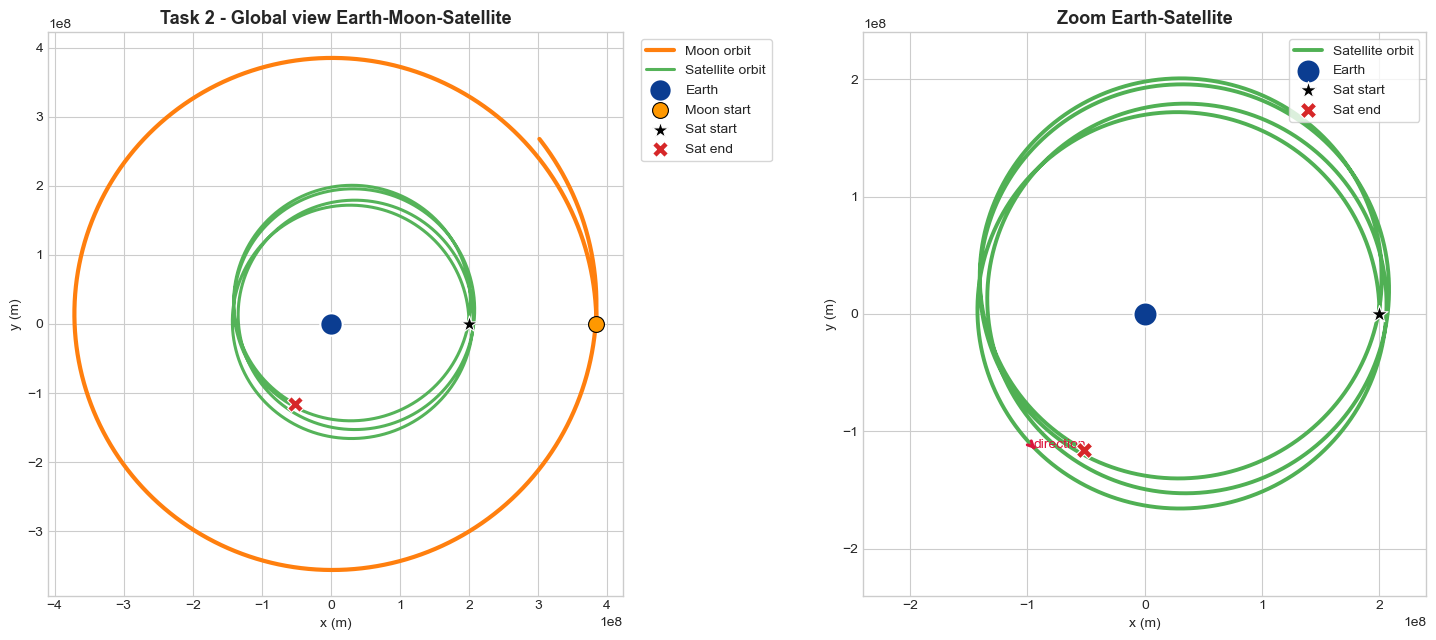

In [7]:
p = res2["positions"]
xE, yE = p[:,0,0], p[:,0,1]
xM, yM = p[:,1,0], p[:,1,1]
xS, yS = p[:,2,0], p[:,2,1]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))

ax[0].plot(xM, yM, color="#ff7f0e", lw=3.0, label="Moon orbit")
ax[0].plot(xS, yS, color="#4caf50", lw=2.2, alpha=0.95, label="Satellite orbit")
ax[0].scatter(xE[0], yE[0], s=260, color="#0b3d91", edgecolor="white", linewidth=1.5, zorder=6, label="Earth")
ax[0].scatter(xM[0], yM[0], s=130, color="#ff9800", marker="o", edgecolor="black", linewidth=0.8, zorder=7, label="Moon start")
ax[0].scatter(xS[0], yS[0], s=150, color="black", marker="*", edgecolor="white", linewidth=0.8, zorder=7, label="Sat start")
ax[0].scatter(xS[-1], yS[-1], s=130, color="#d62728", marker="X", edgecolor="white", linewidth=0.8, zorder=7, label="Sat end")
ax[0].set_title("Task 2 - Global view Earth-Moon-Satellite", fontsize=13, weight="bold")
ax[0].set_xlabel("x (m)"); ax[0].set_ylabel("y (m)")
ax[0].set_aspect("equal", adjustable="box")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=10, frameon=True)

ax[1].plot(xS, yS, color="#4caf50", lw=2.8, alpha=0.98, label="Satellite orbit")
ax[1].scatter(xE[0], yE[0], s=300, color="#0b3d91", edgecolor="white", linewidth=1.5, zorder=6, label="Earth")
ax[1].scatter(xS[0], yS[0], s=165, color="black", marker="*", edgecolor="white", linewidth=0.8, zorder=7, label="Sat start")
ax[1].scatter(xS[-1], yS[-1], s=140, color="#d62728", marker="X", edgecolor="white", linewidth=0.8, zorder=7, label="Sat end")

k = len(xS)//6
ax[1].annotate("", xy=(xS[k+20], yS[k+20]), xytext=(xS[k], yS[k]),
               arrowprops=dict(arrowstyle="->", lw=2.2, color="crimson"))
ax[1].text(xS[k], yS[k], "direction", color="crimson", fontsize=10)

r_zoom = 2.4e8
ax[1].set_xlim(-r_zoom, r_zoom); ax[1].set_ylim(-r_zoom, r_zoom)
ax[1].set_title("Zoom Earth-Satellite", fontsize=13, weight="bold")
ax[1].set_xlabel("x (m)"); ax[1].set_ylabel("y (m)")
ax[1].set_aspect("equal", adjustable="box")
ax[1].legend(loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Task 3</h3>

</div>

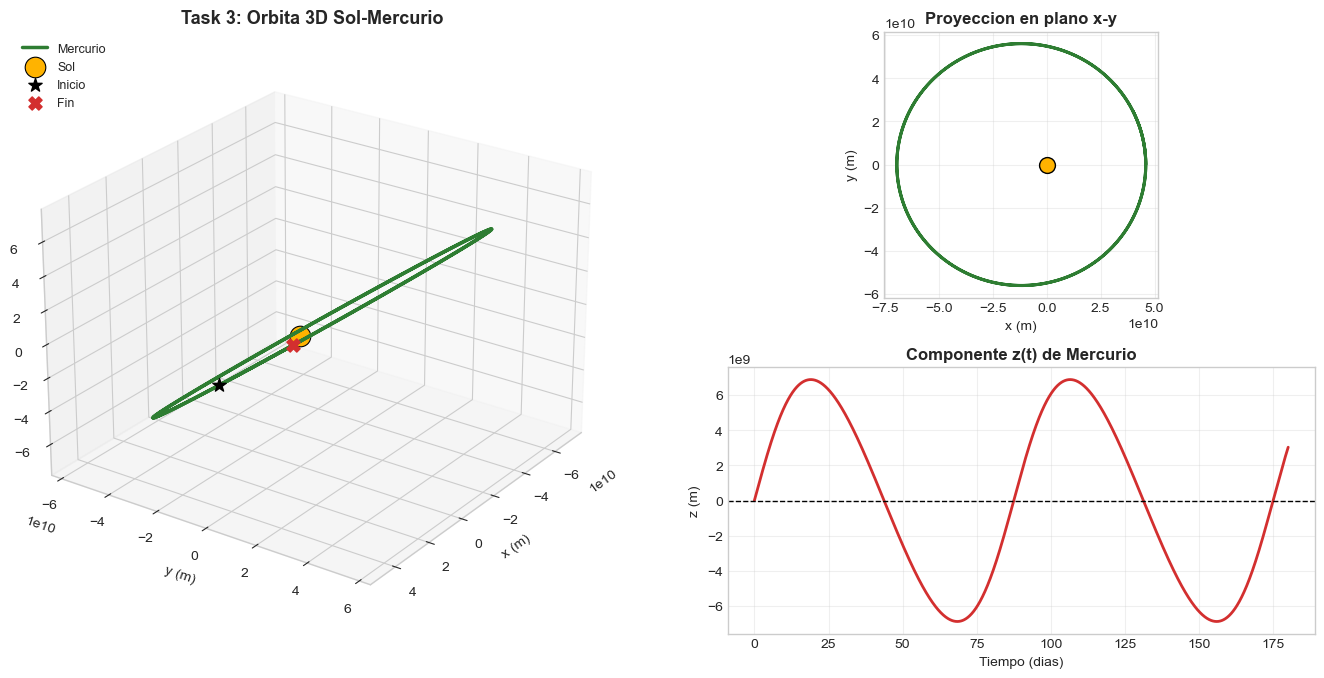

Max |z| Mercurio = 6.882e+09 m


In [12]:
# Task 3 - 3D + XY + z(t)
p = res3["positions"][:, 1, :]
t = res3["time"]

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 7))
gs = GridSpec(2, 2, figure=fig, width_ratios=[1.25, 1], height_ratios=[1, 1])

# Orbita 3D
ax3d = fig.add_subplot(gs[:, 0], projection="3d")
ax3d.plot(p[:,0], p[:,1], p[:,2], color="#2e7d32", lw=2.5, label="Mercurio")
ax3d.scatter(0, 0, 0, s=220, color="#ffb300", edgecolor="black", linewidth=0.8, label="Sol")
ax3d.scatter(p[0,0], p[0,1], p[0,2], s=100, color="black", marker="*", label="Inicio")
ax3d.scatter(p[-1,0], p[-1,1], p[-1,2], s=90, color="#d32f2f", marker="X", label="Fin")
ax3d.set_title("Task 3: Orbita 3D Sol-Mercurio", fontsize=13, weight="bold")
ax3d.set_xlabel("x (m)")
ax3d.set_ylabel("y (m)")
ax3d.set_zlabel("z (m)")
ax3d.view_init(elev=25, azim=35)
ax3d.legend(loc="upper left", fontsize=9)

#Proyeccion XY 
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.plot(p[:,0], p[:,1], color="#2e7d32", lw=2.2)
ax_xy.scatter(0, 0, s=130, color="#ffb300", edgecolor="black")
ax_xy.set_title("Proyeccion en plano x-y", fontsize=12, weight="bold")
ax_xy.set_xlabel("x (m)")
ax_xy.set_ylabel("y (m)")
ax_xy.set_aspect("equal", adjustable="box")
ax_xy.grid(alpha=0.3)

#z(t)
ax_z = fig.add_subplot(gs[1, 1])
ax_z.plot(t/86400.0, p[:,2], color="#d32f2f", lw=2.0)
ax_z.axhline(0, color="black", ls="--", lw=1)
ax_z.set_title("Componente z(t) de Mercurio", fontsize=12, weight="bold")
ax_z.set_xlabel("Tiempo (dias)")
ax_z.set_ylabel("z (m)")
ax_z.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max |z| Mercurio = {np.max(np.abs(p[:,2])):.3e} m")


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Conclusión de Fase III (Task 1, 2 y 3)</h3>

Estos tres ejercicios muestran claramente cómo el modelo va escalando en complejidad, pero manteniendo consistencia física en cada etapa.  

En <b>Task 1 (2 cuerpos)</b> se recupera el caso base: una órbita Tierra-satélite prácticamente circular, donde además se puede medir el <i>drift</i> numérico y establecer qué tan bien se comporta el integrador.  

En <b>Task 2 (3 cuerpos restringido)</b> ya no estamos en el mundo ideal: la Luna introduce perturbaciones visibles en la trayectoria, lo que confirma que el modelo responde correctamente a interacciones gravitacionales adicionales.  

En <b>Task 3 (expansión 3D Sol-Mercurio)</b> el sistema deja de ser plano: la proyección en $x$-$y$ se mantiene coherente, pero aparece una dinámica real en $z(t)$, con $\max|z| = 6.882\times10^9\ \text{m}$, evidenciando evolución tridimensional.

<br>

En conjunto, los resultados no solo son físicamente coherentes, sino que muestran que el solver es robusto: pasa de un problema clásico de 2 cuerpos a configuraciones 3D más realistas sin perder estabilidad ni consistencia.

</div>
